# Schaefer 100 Pilot Figure Generation

This notebook generates pilot validation figures for one resting-state fMRI run:

```text
sub-PC001 / ses-01 / task-rest / run-1
```

The figures are used as workflow-validation outputs and should not be interpreted as evidence for psychedelic-related effects or group-level findings.


In [12]:
# === Setup ===
from pathlib import Path
import os
import re
import zipfile
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# === Project settings ===
PILOT_ID = "sub-PC001_ses-01_task-rest_run-1"
ATLAS_NAME = "schaefer100"

N_ROI = 100
N_TIMEPOINTS_EXPECTED = 504

# Sliding-window parameters
WINDOW_SIZE = 60
STEP_SIZE = 10
TR = 0.91

# Paths
BASE_DIR = Path("/content")
FIG_DIR = BASE_DIR / "figures"
FIG_DIR.mkdir(exist_ok=True)

# Expected input files
ROI_RAW_PATH = BASE_DIR / f"{PILOT_ID}_{ATLAS_NAME}_roi_timeseries.csv"
ROI_Z_PATH = BASE_DIR / f"{PILOT_ID}_{ATLAS_NAME}_roi_timeseries_z.csv"
STATIC_FC_Z_PATH = BASE_DIR / f"{PILOT_ID}_{ATLAS_NAME}_static_fc_fisher_z.csv"

DFC_ZIP_PATH = BASE_DIR / f"fc_dfc_{ATLAS_NAME}.zip"
DFC_DIR = BASE_DIR / f"fc_dfc_{ATLAS_NAME}"

print("Pilot ID:", PILOT_ID)
print("Atlas:", ATLAS_NAME)
print("Expected ROIs:", N_ROI)
print("Expected timepoints:", N_TIMEPOINTS_EXPECTED)
print("Figure directory:", FIG_DIR)

Pilot ID: sub-PC001_ses-01_task-rest_run-1
Atlas: schaefer100
Expected ROIs: 100
Expected timepoints: 504
Figure directory: /content/figures


## Required input files
Upload the following Schaefer 100-derived pilot outputs:


1. sub-PC001_ses-01_task-rest_run-1_schaefer100_roi_timeseries.csv
2. sub-PC001_ses-01_task-rest_run-1_schaefer100_roi_timeseries_z.csv
3. sub-PC001_ses-01_task-rest_run-1_schaefer100_static_fc_fisher_z.csv
4. fc_dfc_schaefer100.zip

Note: From the sFC stage onward, this notebook uses Fisher-z transformed FC matrices as the main visualization and analysis format.

In [1]:
# upload roi_timeseries
from google.colab import files
uploaded = files.upload()

Saving sub-PC001_ses-01_task-rest_run-1_schaefer100_roi_timeseries.csv to sub-PC001_ses-01_task-rest_run-1_schaefer100_roi_timeseries.csv


In [3]:
# upload roi_timeseries.z
from google.colab import files
uploaded = files.upload()

Saving sub-PC001_ses-01_task-rest_run-1_schaefer100_roi_timeseries_z.csv to sub-PC001_ses-01_task-rest_run-1_schaefer100_roi_timeseries_z.csv


In [4]:
# upload static fc fisher-z
from google.colab import files
uploaded = files.upload()

Saving sub-PC001_ses-01_task-rest_run-1_static_fc_fisher_z.csv to sub-PC001_ses-01_task-rest_run-1_static_fc_fisher_z.csv


In [5]:
print("\nFiles in current directory:")
for f in os.listdir("."):
    print(f)


Files in current directory:
.config
figures
sub-PC001_ses-01_task-rest_run-1_schaefer100_roi_timeseries.csv
drive
sub-PC001_ses-01_task-rest_run-1_static_fc_fisher_z.csv
sub-PC001_ses-01_task-rest_run-1_schaefer100_roi_timeseries_z.csv
sample_data


In [15]:


# raw
print("Loading raw ROI time series:")
roi_path = "/content/sub-PC001_ses-01_task-rest_run-1_schaefer100_roi_timeseries.csv"

df = pd.read_csv(roi_path)
print(df.head())

arr = df.select_dtypes(include=[np.number]).values
print("Numeric array shape:", arr.shape,"\n")

# 如果列數 (Time) 小於行數 (ROI)，代表矩陣躺平了，我們把它轉置 (Transpose) 回來
if arr.shape[0] < arr.shape[1]:
    ts = arr.T
else:
    ts = arr

# z-score
print("\nLoading z-scored ROI time series:")
print("z-score array")
roi_path = "/content/sub-PC001_ses-01_task-rest_run-1_schaefer100_roi_timeseries_z.csv"
df = pd.read_csv(roi_path)

print(df.head())
arr_z = df.select_dtypes(include=[np.number]).values
print("z-score Numeric array shape:", arr_z.shape)

if arr_z.shape[0] < arr_z.shape[1]:
    ts_z = arr_z.T
else:
    ts_z = arr_z

Loading raw ROI time series:
     ROI_001    ROI_002    ROI_003    ROI_004    ROI_005    ROI_006  \
0  4149.4670  3510.2100  4128.1914  3340.2317  3439.3733  3968.3540   
1  4137.1597  3497.2202  4108.2270  3329.8708  3417.7058  3959.0396   
2  4138.2820  3486.1643  4101.1665  3327.2568  3418.3354  3960.7932   
3  4131.3564  3486.1248  4084.2483  3326.4688  3412.7756  3967.7168   
4  4140.3310  3483.1697  4082.7373  3329.4763  3412.6855  3964.7737   

     ROI_007    ROI_008    ROI_009    ROI_010  ...    ROI_091    ROI_092  \
0  3798.1840  3619.2634  3633.8433  4102.7383  ...  3094.8350  3683.5535   
1  3791.6462  3606.4290  3620.6343  4079.2240  ...  3073.1528  3658.0680   
2  3792.3594  3604.0688  3614.7031  4075.4950  ...  3066.2278  3646.6650   
3  3797.8230  3600.5757  3611.6470  4067.9980  ...  3070.3480  3648.2126   
4  3788.3633  3600.5550  3612.3090  4060.8590  ...  3073.8180  3643.0562   

     ROI_093    ROI_094    ROI_095    ROI_096    ROI_097    ROI_098  \
0  3630.4006  33

## ROI extraction

### plot 2 heatmap (raw + z-score)

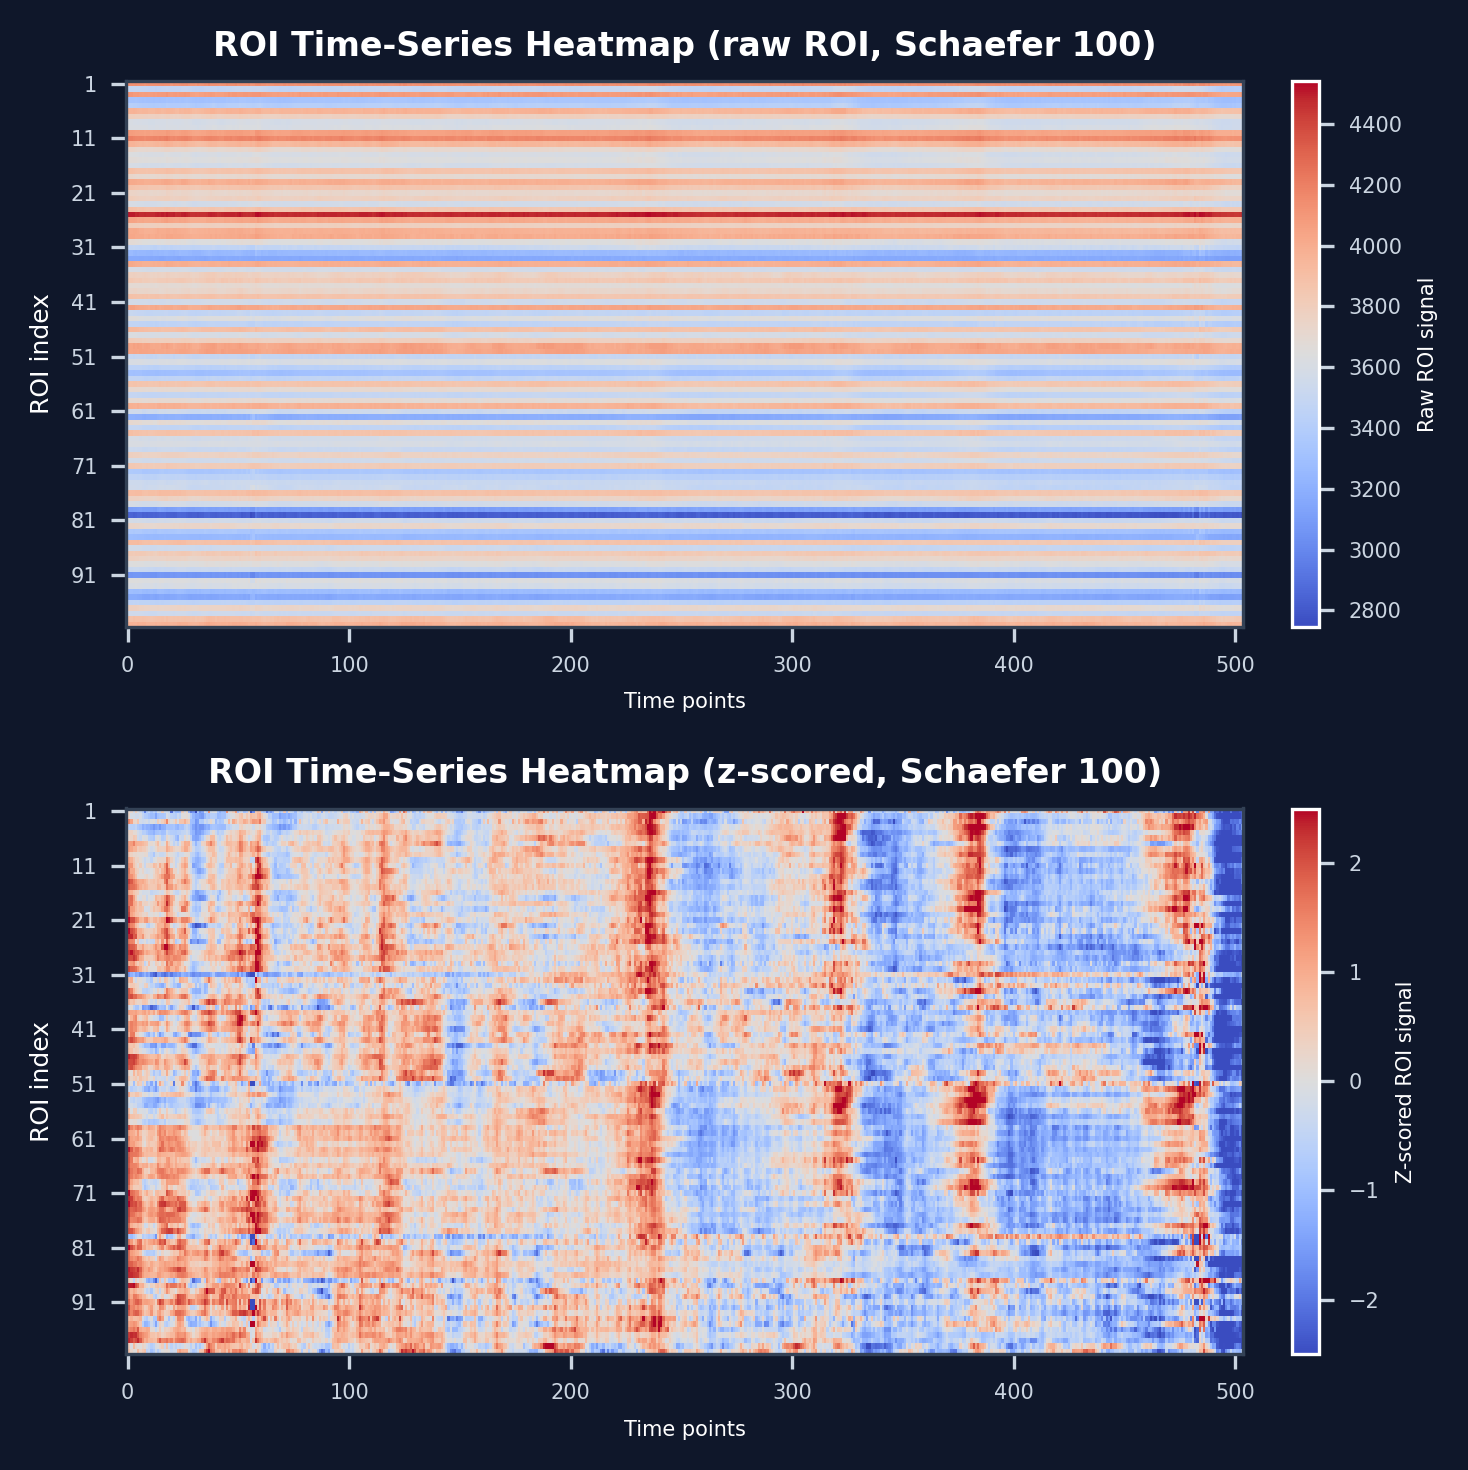

Saved: /content/figures/schaefer100_roi_timeseries_heatmap_combined.png


In [11]:
plt.style.use("dark_background")

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(5, 5), dpi=300)

plot_configs = [
    {
        "data": ts.T,
        "title": "ROI Time-Series Heatmap (raw ROI, Schaefer 100)",
        "label": "Raw ROI signal",
        "vmin": None,
        "vmax": None
    },
    {
        "data": ts_z.T,
        "title": "ROI Time-Series Heatmap (z-scored, Schaefer 100)",
        "label": "Z-scored ROI signal",
        "vmin": -2.5,
        "vmax": 2.5
    }
]

for ax, config in zip(axes, plot_configs):
    im = ax.imshow(
        config["data"],
        aspect="auto",
        cmap="coolwarm",
        interpolation="nearest",
        vmin=config["vmin"],
        vmax=config["vmax"]
    )

    ax.set_title(config["title"], fontsize=8, weight="bold", color="white")
    ax.set_xlabel("Time points", fontsize=5, color="white")
    ax.set_ylabel("ROI index", fontsize=6, color="white")

    ax.set_yticks(np.arange(0, config["data"].shape[0], 10))
    ax.set_yticklabels(np.arange(1, config["data"].shape[0] + 1, 10), fontsize=5)
    ax.tick_params(colors="#cbd5e1", labelsize=5)

    ax.set_facecolor("#0f172a")
    for spine in ax.spines.values():
        spine.set_color("#334155")

    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(config["label"], color="white", fontsize=5)
    cbar.ax.yaxis.set_tick_params(color="#cbd5e1", labelsize=5)
    plt.setp(cbar.ax.get_yticklabels(), color="#cbd5e1")

fig.patch.set_facecolor("#0f172a")

out = FIG_DIR / "schaefer100_roi_timeseries_heatmap_combined.png"
plt.tight_layout()
plt.savefig(out, dpi=300, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

print("Saved:", out)


## sFC

### sFC matrices

Static FC Fisher-z matrix shape: (100, 100)


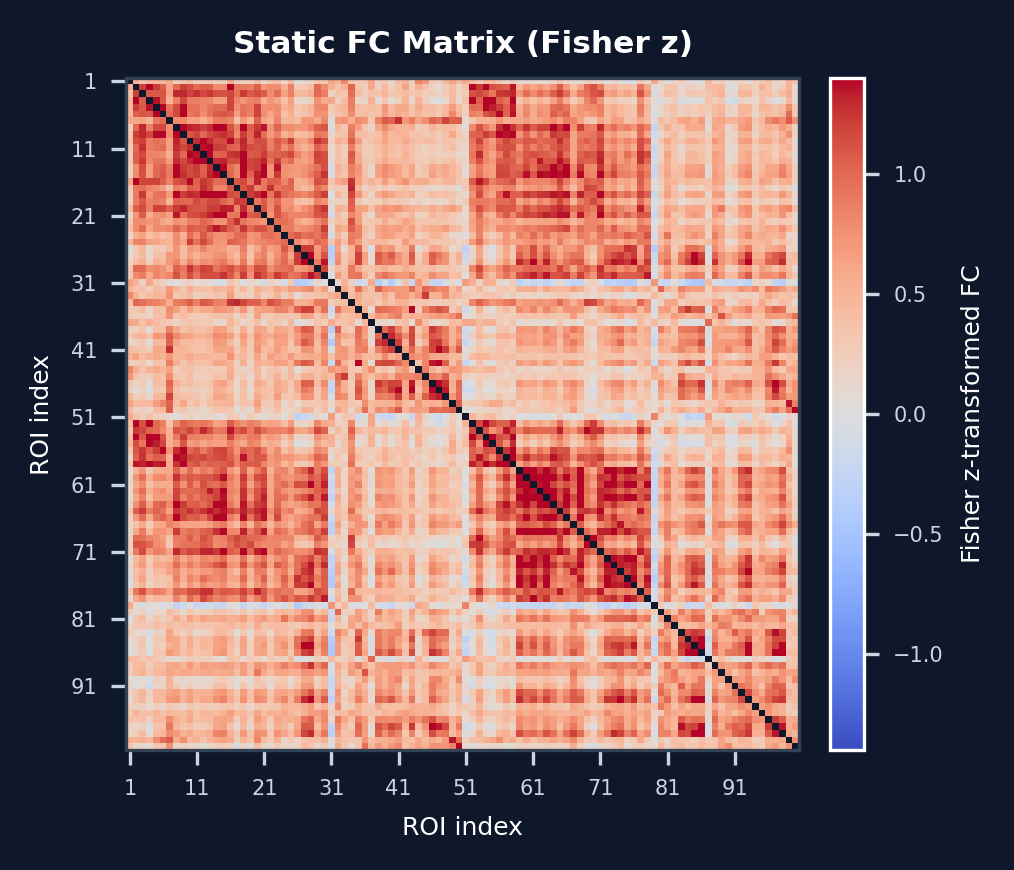

Saved: figures/schaefer100_static_fc.png


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 讀取並處理 Fisher-z sFC
fc_z_path = "/content/sub-PC001_ses-01_task-rest_run-1_static_fc_fisher_z.csv"
#本地端：
# fc_z_path = "/Users/macbookair/brain-dynamics-psilocybin/outputs/fc_dfc_preliminary_grid/sub-PC001_ses-01_task-rest_run-1_static_fc_fisher_z.csv"

fc_z = pd.read_csv(fc_z_path, index_col=0).values.astype(float)
np.fill_diagonal(fc_z, np.nan) # Mask diagonal
print("Static FC Fisher-z matrix shape:", fc_z.shape)
n_roi = fc_z.shape[0]
if fc_z.shape != (n_roi, n_roi):
    raise ValueError(f"Expected {(n_roi, n_roi)}, got {fc_z.shape}")

vmax_z = np.nanpercentile(np.abs(fc_z), 98)

# === Plot Fisher-z Static FC Matrix ===
plt.style.use("dark_background")

# 1. 畫布長寬減半
fig, ax = plt.subplots(figsize=(3.5, 3), dpi=300)

im = ax.imshow(
    fc_z,
    cmap="coolwarm",
    vmin=-vmax_z,
    vmax=vmax_z,
    interpolation="nearest"
)

# 2. 標題字體減半
ax.set_title(
    "Static FC Matrix (Fisher z)",
    fontsize=7.5,
    weight="bold",
    color="white"
)

# 3. 軸標籤字體減半
ax.set_xlabel("ROI index", fontsize=6, color="white")
ax.set_ylabel("ROI index", fontsize=6, color="white")

tick_positions = np.arange(0, n_roi, 10)
tick_labels = np.arange(1, n_roi + 1, 10)

ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels)
ax.set_yticks(tick_positions)
ax.set_yticklabels(tick_labels)

# 4. 新增 labelsize 將座標軸的數字減半
ax.tick_params(colors="#cbd5e1", labelsize=5)

ax.set_facecolor("#0f172a")
for spine in ax.spines.values():
    spine.set_color("#334155")

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# 5. Colorbar 的標籤與數字字體減半
cbar.set_label("Fisher z-transformed FC", color="white", fontsize=6)
cbar.ax.yaxis.set_tick_params(color="#cbd5e1", labelsize=5)
plt.setp(cbar.ax.get_yticklabels(), color="#cbd5e1")

fig.patch.set_facecolor("#0f172a")

out = f"figures/schaefer100_static_fc.png"
plt.tight_layout()
plt.savefig(out, dpi=300, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

print("Saved:", out)

### sFC descriptive check

=== Static FC Fisher-z Distribution Stats ===
Number of edges: 4950
Mean Fisher-z FC: 0.5998
SD Fisher-z FC: 0.3798
Proportion positive: 0.96
Proportion negative: 0.04

=== Node Strength Stats based on Fisher-z FC ===
Mean node strength: 0.5998
Max node strength ROI: 63 (0.8369)
Min node strength ROI: 79 (-0.0113)


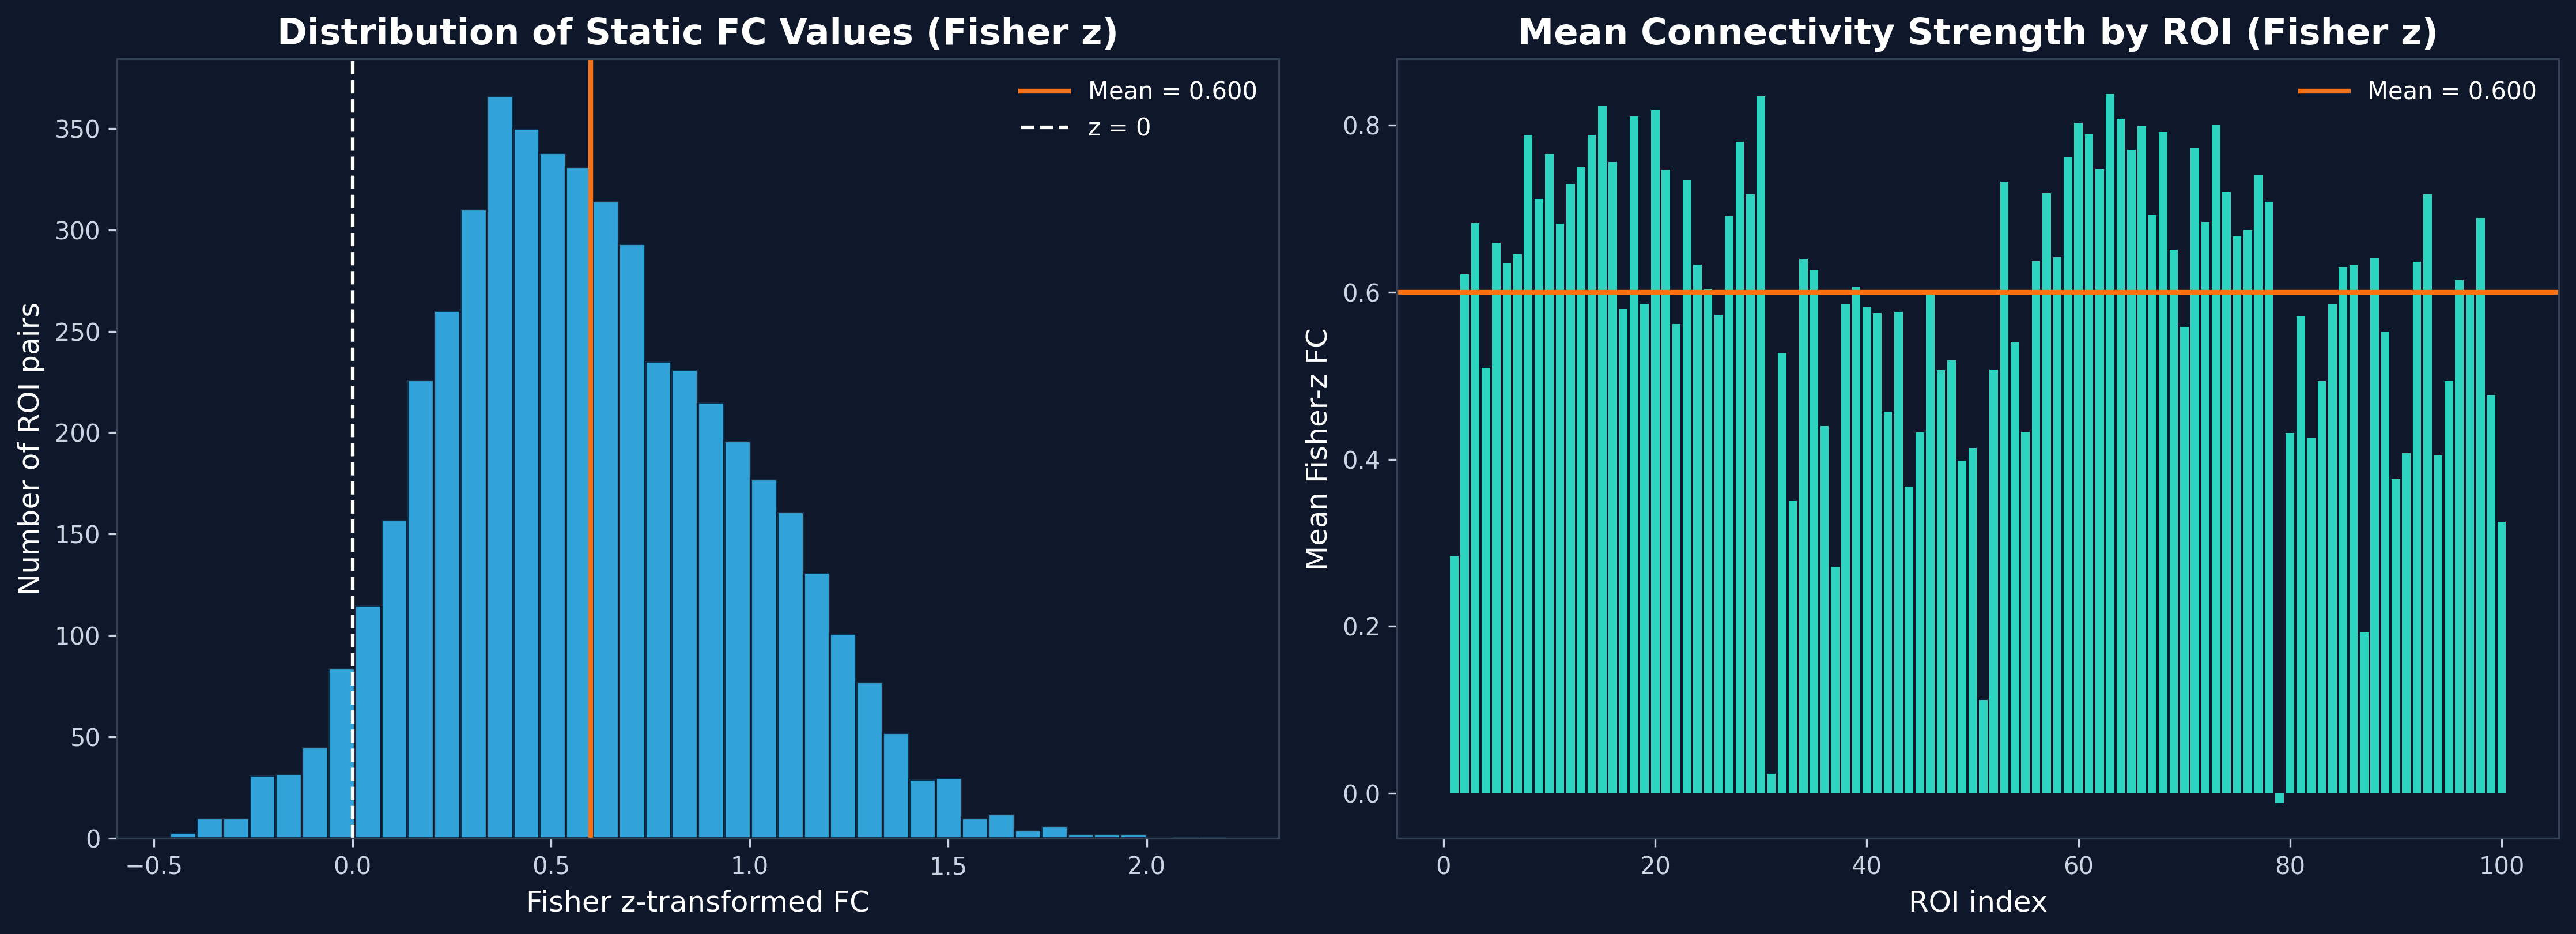

Saved: figures/schaefer100_static_fc_stats.png


In [23]:
# fix
# === 1) Load Static FC ===
fc_z_path = "/content/sub-PC001_ses-01_task-rest_run-1_static_fc_fisher_z.csv"

# === Load Static FC Fisher-z ===
fc_z = pd.read_csv(fc_z_path, index_col=0).values.astype(float)

n = fc_z.shape[0]
upper_idx = np.triu_indices(n, k=1)
edges_z = fc_z[upper_idx]

# Remove possible nan / inf
edges_z = edges_z[np.isfinite(edges_z)]

print("=== Static FC Fisher-z Distribution Stats ===")
print(f"Number of edges: {len(edges_z)}")
print(f"Mean Fisher-z FC: {np.mean(edges_z):.4f}")
print(f"SD Fisher-z FC: {np.std(edges_z):.4f}")
print(f"Proportion positive: {np.mean(edges_z > 0):.2f}")
print(f"Proportion negative: {np.mean(edges_z < 0):.2f}")

# === Node strength based on Fisher-z FC ===
fc_z_no_diag = fc_z.copy()
np.fill_diagonal(fc_z_no_diag, np.nan)
node_strength_z = np.nanmean(fc_z_no_diag, axis=1)

print("\n=== Node Strength Stats based on Fisher-z FC ===")
print(f"Mean node strength: {np.nanmean(node_strength_z):.4f}")
print(f"Max node strength ROI: {np.nanargmax(node_strength_z) + 1} ({np.nanmax(node_strength_z):.4f})")
print(f"Min node strength ROI: {np.nanargmin(node_strength_z) + 1} ({np.nanmin(node_strength_z):.4f})")

# === Plot Combined Figure ===
plt.style.use("dark_background")
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 5.5), dpi=300)

# Histogram
ax1 = axes[0]
ax1.hist(edges_z, bins=40, color="#38bdf8", alpha=0.85, edgecolor="#0f172a")
ax1.axvline(np.mean(edges_z), color="#f97316", linewidth=2, label=f"Mean = {np.mean(edges_z):.3f}")
ax1.axvline(0, color="white", linewidth=1.5, linestyle="--", label="z = 0")
ax1.set_title("Distribution of Static FC Values (Fisher z)", fontsize=15, weight="bold", color="white")
ax1.set_xlabel("Fisher z-transformed FC", fontsize=12, color="white")
ax1.set_ylabel("Number of ROI pairs", fontsize=12, color="white")
ax1.legend(frameon=False, labelcolor="white")

# Node strength
ax2 = axes[1]
ax2.bar(np.arange(1, len(node_strength_z) + 1), node_strength_z, color="#2dd4bf")
ax2.axhline(np.nanmean(node_strength_z), color="#f97316", linewidth=2, label=f"Mean = {np.nanmean(node_strength_z):.3f}")
ax2.set_title("Mean Connectivity Strength by ROI (Fisher z)", fontsize=15, weight="bold", color="white")
ax2.set_xlabel("ROI index", fontsize=12, color="white")
ax2.set_ylabel("Mean Fisher-z FC", fontsize=12, color="white")
ax2.legend(frameon=False, labelcolor="white")

# Styling
fig.patch.set_facecolor("#0f172a")
for ax in axes:
    ax.set_facecolor("#0f172a")
    ax.tick_params(colors="#cbd5e1")
    for spine in ax.spines.values():
        spine.set_color("#334155")

out = f"figures/schaefer100_static_fc_stats.png"
plt.tight_layout()
plt.savefig(out, dpi=300, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

print("Saved:", out)



=== Distribution Stats ===
Number of edges: 4950
Mean FC: 0.4882 | SD FC: 0.2573
Proportion pos: 0.96 | Proportion neg: 0.04

=== Node Strength Stats ===
Mean node strength: 0.4882
Max node strength ROI: 30 (0.6467)
Min node strength ROI: 79 (-0.0152)


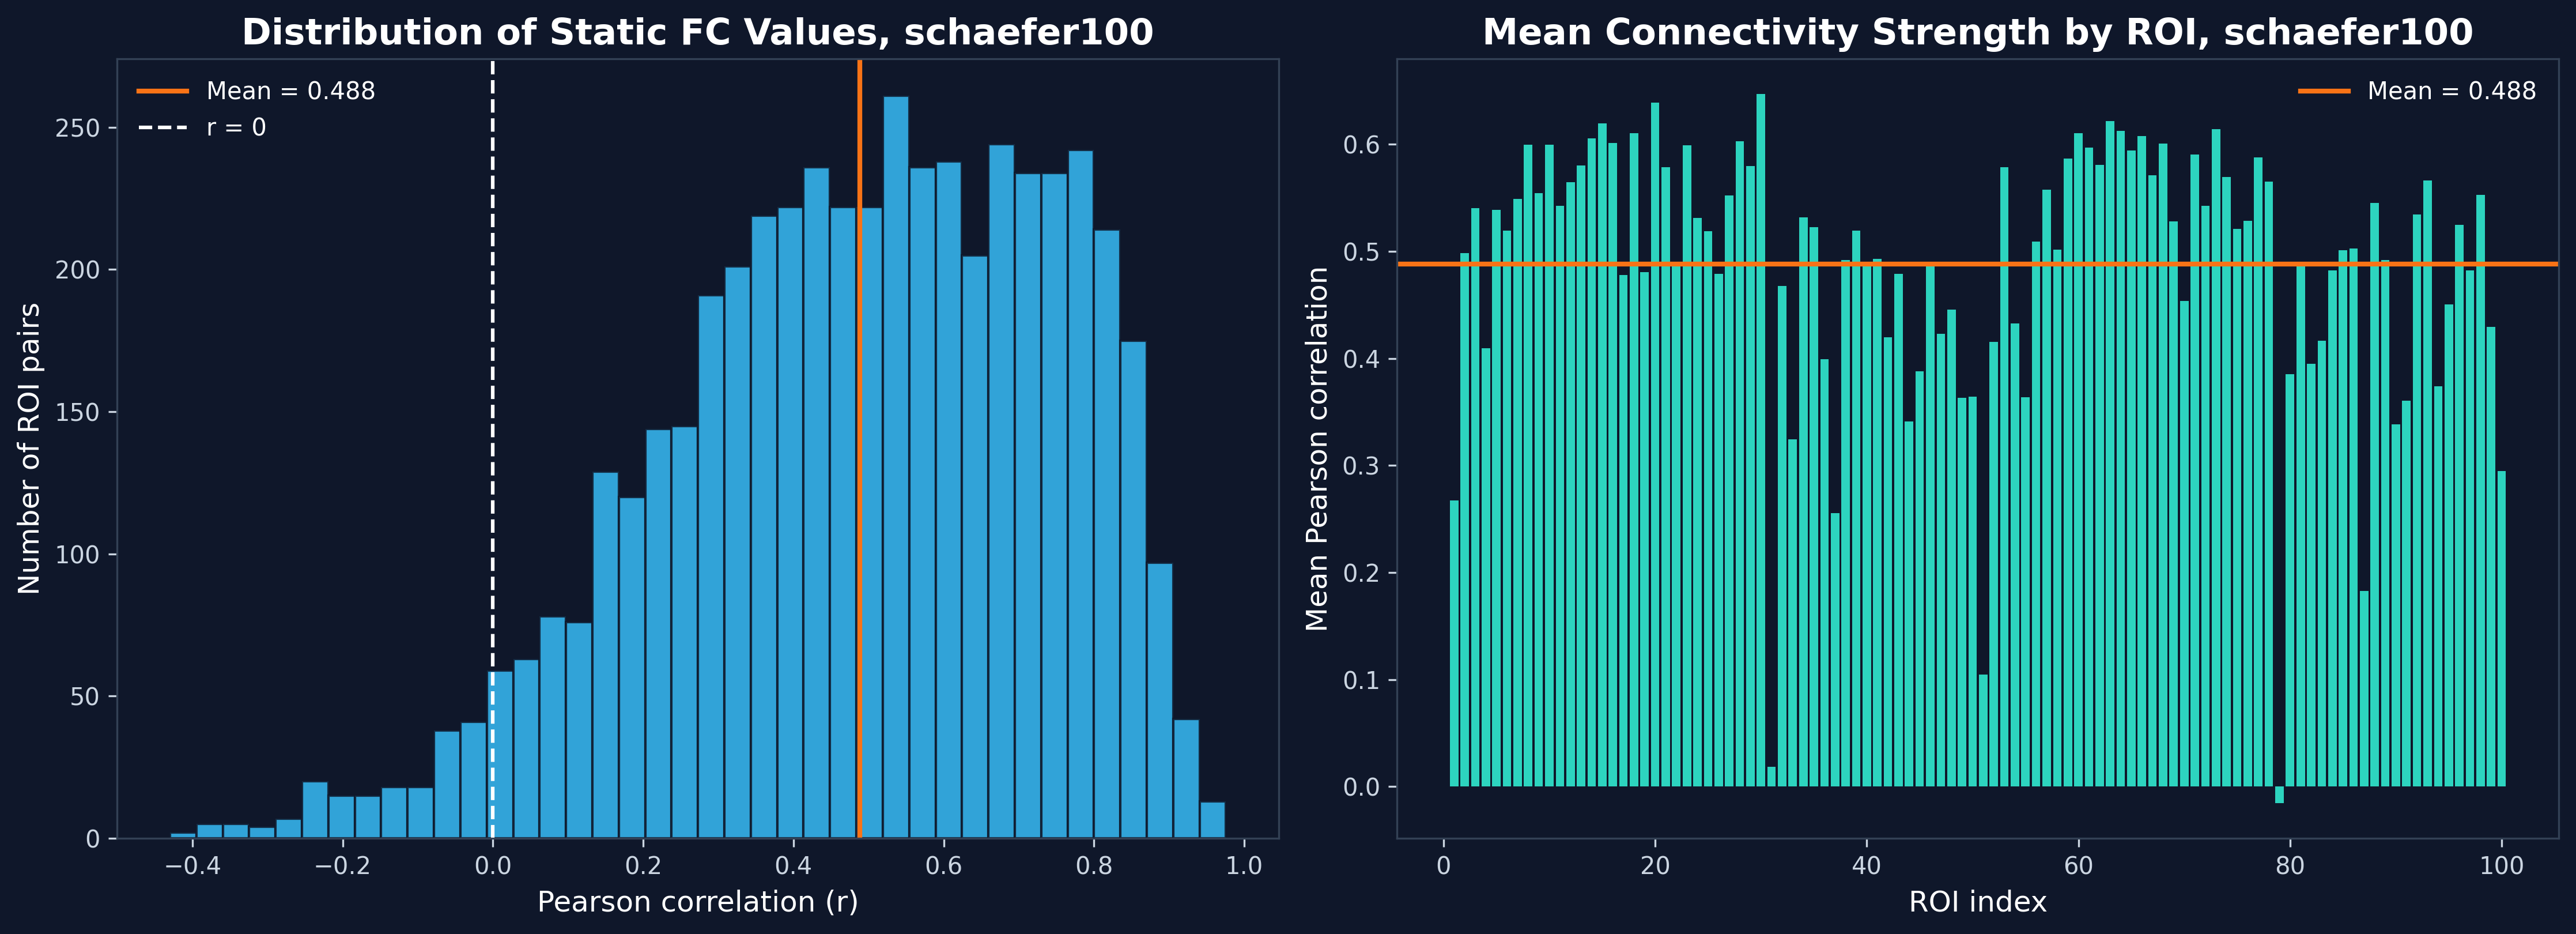


Saved combined image to: /content/static_fc_stats_combined_dark.png


In [ ]:
# old ver.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load Static FC
fc_path = "/content/sub-PC001_ses-01_task-rest_run-1_static_fc.csv"
fc_df = pd.read_csv(fc_path, index_col=0)
fc = fc_df.values.astype(float)

# Compute Data for Plot 1 (Histogram)
n = fc.shape[0]
upper_idx = np.triu_indices(n, k=1)
edges = fc[upper_idx]

print("=== Distribution Stats ===")
print(f"Number of edges: {len(edges)}")
print(f"Mean FC: {np.mean(edges):.4f} | SD FC: {np.std(edges):.4f}")
print(f"Proportion pos: {np.mean(edges > 0):.2f} | Proportion neg: {np.mean(edges < 0):.2f}")

# Compute Data for Plot 2
fc_no_diag = fc.copy()
np.fill_diagonal(fc_no_diag, np.nan)
node_strength = np.nanmean(fc_no_diag, axis=1)

print("\n=== Node Strength Stats ===")
print(f"Mean node strength: {np.mean(node_strength):.4f}")
print(f"Max node strength ROI: {np.argmax(node_strength) + 1} ({np.max(node_strength):.4f})")
print(f"Min node strength ROI: {np.argmin(node_strength) + 1} ({np.min(node_strength):.4f})")

plt.style.use("dark_background")
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 5.5), dpi=300)

# Subplot 1: Histogram (axes[0])
ax1 = axes[0]
ax1.hist(edges, bins=40, color="#38bdf8", alpha=0.85, edgecolor="#0f172a")
ax1.axvline(np.mean(edges), color="#f97316", linewidth=2, label=f"Mean = {np.mean(edges):.3f}")
ax1.axvline(0, color="white", linewidth=1.5, linestyle="--", label="r = 0")
ax1.set_title("Distribution of Static FC Values, schaefer100", fontsize=15, weight="bold", color="white")
ax1.set_xlabel("Pearson correlation (r)", fontsize=12, color="white")
ax1.set_ylabel("Number of ROI pairs", fontsize=12, color="white")
ax1.legend(frameon=False, labelcolor="white")

# Subplot 2: Bar Chart (axes[1])
ax2 = axes[1]
ax2.bar(np.arange(1, len(node_strength) + 1), node_strength, color="#2dd4bf")
ax2.axhline(np.mean(node_strength), color="#f97316", linewidth=2, label=f"Mean = {np.mean(node_strength):.3f}")
ax2.set_title("Mean Connectivity Strength by ROI, schaefer100", fontsize=15, weight="bold", color="white")
ax2.set_xlabel("ROI index", fontsize=12, color="white")
ax2.set_ylabel("Mean Pearson correlation", fontsize=12, color="white")
ax2.legend(frameon=False, labelcolor="white")

# Global Style Adjustments
fig.patch.set_facecolor("#0f172a")
for ax in axes:
    ax.set_facecolor("#0f172a")
    ax.tick_params(colors="#cbd5e1")
    for spine in ax.spines.values():
        spine.set_color("#334155")

# Save and show
out = "/content/static_fc_stats_combined_dark.png"
plt.tight_layout()
plt.savefig(out, dpi=300, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

print(f"\nSaved combined image to: {out}")

## dFC

### upload fc_dfc.zip

In [24]:
from google.colab import files
uploaded = files.upload()

Saving fc_dfc_schaefer100.zip to fc_dfc_schaefer100.zip


In [25]:
import zipfile
import os

zip_path = "/content/fc_dfc_schaefer100.zip"
out_dir = "/content"

os.makedirs(out_dir, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(out_dir)

print("Extracted files:")
print(os.listdir(out_dir)[:10])

Extracted files:
['.config', '__MACOSX', 'figures', 'sub-PC001_ses-01_task-rest_run-1_schaefer100_roi_timeseries.csv', 'drive', 'fc_dfc_schaefer100.zip', 'fc_dfc_schaefer100', 'sub-PC001_ses-01_task-rest_run-1_static_fc_fisher_z.csv', 'sub-PC001_ses-01_task-rest_run-1_schaefer100_roi_timeseries_z.csv', 'sample_data']


In [26]:
print("目前目錄路徑:", Path(".").absolute())
print("資料夾是否存在:", Path("fc_dfc_schaefer100").exists())

目前目錄路徑: /content
資料夾是否存在: True


In [27]:
from pathlib import Path
import re

folder = Path("/content/fc_dfc_schaefer100")

window_files = sorted(folder.rglob("sub-PC001_ses-01_task-rest_run-1_window-*_fc_fisher_z.csv"))

print("Number of window files found:", len(window_files))

for f in window_files[:5]:
    print("Example file:", f.name)

if len(window_files) == 0:
    raise FileNotFoundError("No window files found. Check your folder path.")


Number of window files found: 45
Example file: sub-PC001_ses-01_task-rest_run-1_window-000_fc_fisher_z.csv
Example file: sub-PC001_ses-01_task-rest_run-1_window-001_fc_fisher_z.csv
Example file: sub-PC001_ses-01_task-rest_run-1_window-002_fc_fisher_z.csv
Example file: sub-PC001_ses-01_task-rest_run-1_window-003_fc_fisher_z.csv
Example file: sub-PC001_ses-01_task-rest_run-1_window-004_fc_fisher_z.csv


In [30]:
def get_window_id(path):
    match = re.search(r"window-(\d+)", path.name)
    if match is None:
        raise ValueError(f"Cannot parse window id from {path.name}")
    return int(match.group(1))

window_files = sorted(window_files, key=get_window_id)
window_ids = np.array([get_window_id(f) for f in window_files])

print("Window IDs:", window_ids[:10], "...", window_ids[-5:])
print("Number of windows:", len(window_ids))


Window IDs: [0 1 2 3 4 5 6 7 8 9] ... [40 41 42 43 44]
Number of windows: 45


In [29]:
mats = []

for f in window_files:
    df = pd.read_csv(f, index_col=0)
    mat = df.values.astype(float)

    # basic check
    if mat.shape != (100, 100):
        raise ValueError(f"Unexpected shape {mat.shape} in {f.name}")

    # mask diagonal because Fisher z diagonal is artificially large
    np.fill_diagonal(mat, np.nan)

    mats.append(mat)

mats = np.stack(mats, axis=0)  # shape: windows x ROI x ROI

print("dFC array shape:", mats.shape)
print("Expected: number_of_windows x" ,N_ROI ,"x" ,N_ROI)
print("Min:", np.nanmin(mats))
print("Max:", np.nanmax(mats))


dFC array shape: (45, 100, 100)
Expected: number_of_windows x 100 x 100
Min: -1.4358767073114358
Max: 2.7431257783583267


### dFC 1: Mean connectivity across sliding windows

Mean of window-level mean FC: 0.4983130191805039
SD of window-level mean FC: 0.19324953569031486
Min window mean FC: 0.13361719107234307
Max window mean FC: 0.888035183560994


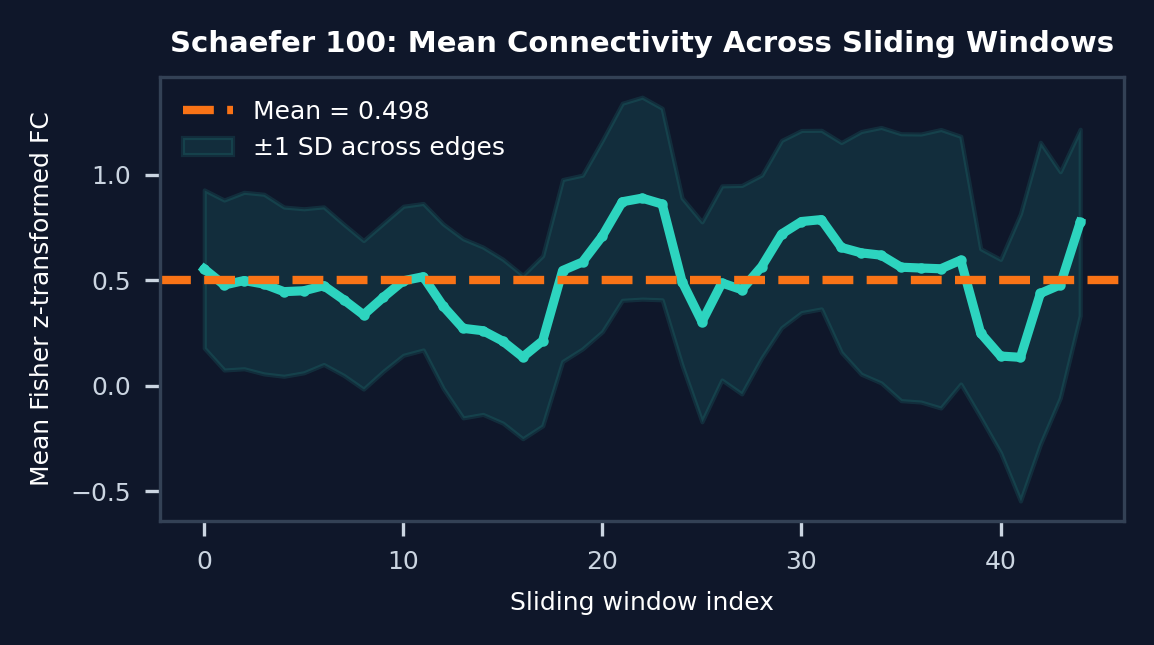

Saved: /content/figures/schaefer100_dfc_mean_connectivity_timecourse.png


In [31]:
# === Compute mean and SD of edge values for each window ===
n_windows, n_roi, _ = mats.shape
upper_idx = np.triu_indices(n_roi, k=1)

mean_fc_per_window = []
sd_fc_per_window = []

for w in range(n_windows):
    edges = mats[w][upper_idx]
    mean_fc_per_window.append(np.nanmean(edges))
    sd_fc_per_window.append(np.nanstd(edges))

mean_fc_per_window = np.array(mean_fc_per_window)
sd_fc_per_window = np.array(sd_fc_per_window)

print("Mean of window-level mean FC:", np.mean(mean_fc_per_window))
print("SD of window-level mean FC:", np.std(mean_fc_per_window))
print("Min window mean FC:", np.min(mean_fc_per_window))
print("Max window mean FC:", np.max(mean_fc_per_window))

# === Plot ===
plt.style.use("dark_background")
fig, ax = plt.subplots(figsize=(4, 2.25), dpi=300)

ax.plot(
    window_ids,
    mean_fc_per_window,
    color="#2dd4bf",
    linewidth=2.2,
    marker="o",
    markersize=1.5
)

ax.axhline(
    np.mean(mean_fc_per_window),
    color="#f97316",
    linestyle="--",
    linewidth=2,
    label=f"Mean = {np.mean(mean_fc_per_window):.3f}"
)

ax.fill_between(
    window_ids,
    mean_fc_per_window - sd_fc_per_window,
    mean_fc_per_window + sd_fc_per_window,
    color="#2dd4bf",
    alpha=0.12,
    label="±1 SD across edges"
)

ax.set_title("Schaefer 100: Mean Connectivity Across Sliding Windows", fontsize=7, weight="bold", color="white")
ax.set_xlabel("Sliding window index", fontsize=6, color="white")
ax.set_ylabel("Mean Fisher z-transformed FC", fontsize=6, color="white")

ax.tick_params(colors="#cbd5e1", labelsize=6)
ax.legend(frameon=False, labelcolor="white", fontsize=6)

fig.patch.set_facecolor("#0f172a")
ax.set_facecolor("#0f172a")

for spine in ax.spines.values():
    spine.set_color("#334155")

out = FIG_DIR / "schaefer100_dfc_mean_connectivity_timecourse.png"
plt.tight_layout()
plt.savefig(out, dpi=300, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

print("Saved:", out)


dFC variability matrix shape: (100, 100)
Min variability: 0.13918482769218843
Max variability: 0.6894826034953377
Mean variability: 0.35509630018229094


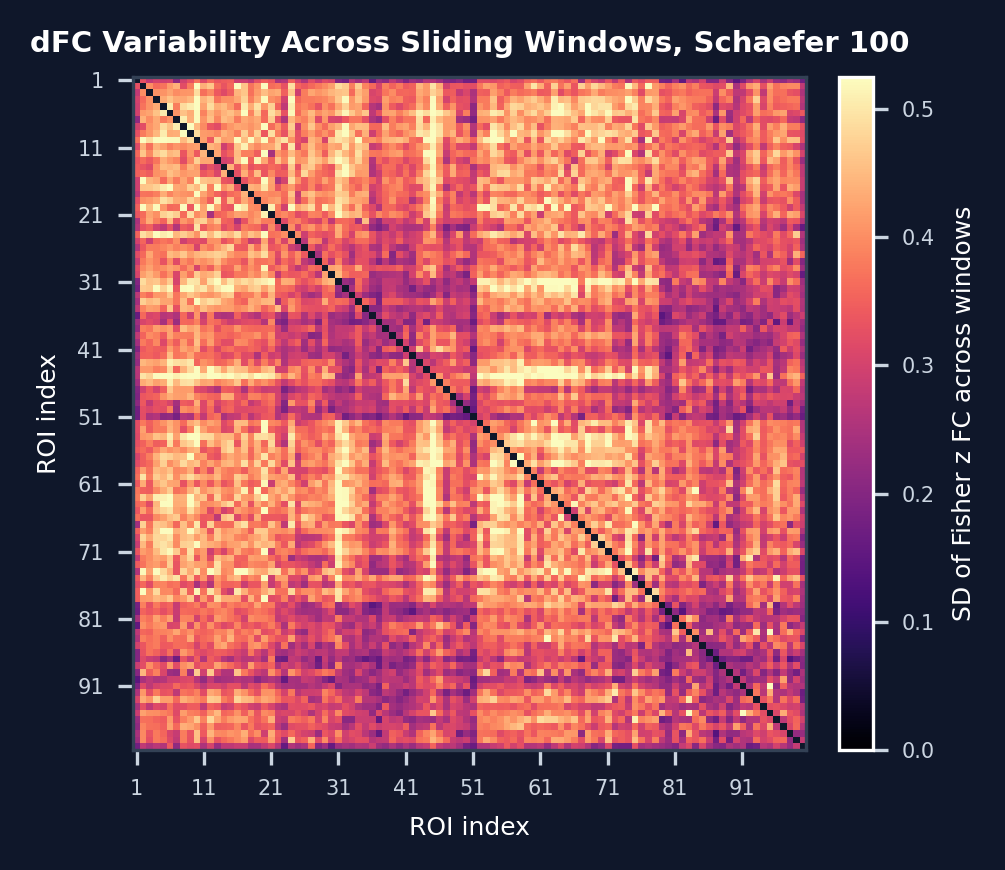

Saved: /content/figures/schaefer100_dfc_variability_matrix.png


In [32]:
# === Compute temporal variability for each edge ===
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=RuntimeWarning)
    dfc_var = np.nanstd(mats, axis=0)

np.fill_diagonal(dfc_var, np.nan)

print("dFC variability matrix shape:", dfc_var.shape)
print("Min variability:", np.nanmin(dfc_var))
print("Max variability:", np.nanmax(dfc_var))
print("Mean variability:", np.nanmean(dfc_var))

vmax = np.nanpercentile(dfc_var, 98)

# === Plot ===
plt.style.use("dark_background")
fig, ax = plt.subplots(figsize=(3.5, 3), dpi=300)

im = ax.imshow(
    dfc_var,
    cmap="magma",
    vmin=0,
    vmax=vmax,
    interpolation="nearest"
)

ax.set_title("dFC Variability Across Sliding Windows, Schaefer 100", fontsize=7, weight="bold", color="white")
ax.set_xlabel("ROI index", fontsize=6, color="white")
ax.set_ylabel("ROI index", fontsize=6, color="white")

tick_positions = np.arange(0, n_roi, 10)
tick_labels = np.arange(1, n_roi + 1, 10)

ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels)
ax.set_yticks(tick_positions)
ax.set_yticklabels(tick_labels)

ax.tick_params(colors="#cbd5e1", labelsize=5)

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("SD of Fisher z FC across windows", color="white", fontsize=6)
cbar.ax.yaxis.set_tick_params(color="#cbd5e1", labelsize=5)
plt.setp(cbar.ax.get_yticklabels(), color="#cbd5e1")

fig.patch.set_facecolor("#0f172a")
ax.set_facecolor("#0f172a")

for spine in ax.spines.values():
    spine.set_color("#334155")

out = FIG_DIR / "schaefer100_dfc_variability_matrix.png"
plt.tight_layout()
plt.savefig(out, dpi=300, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

print("Saved:", out)


Edge vector array shape: (45, 4950)
Window similarity shape: (45, 45)
Min: 0.18683760504556685
Max: 1.0


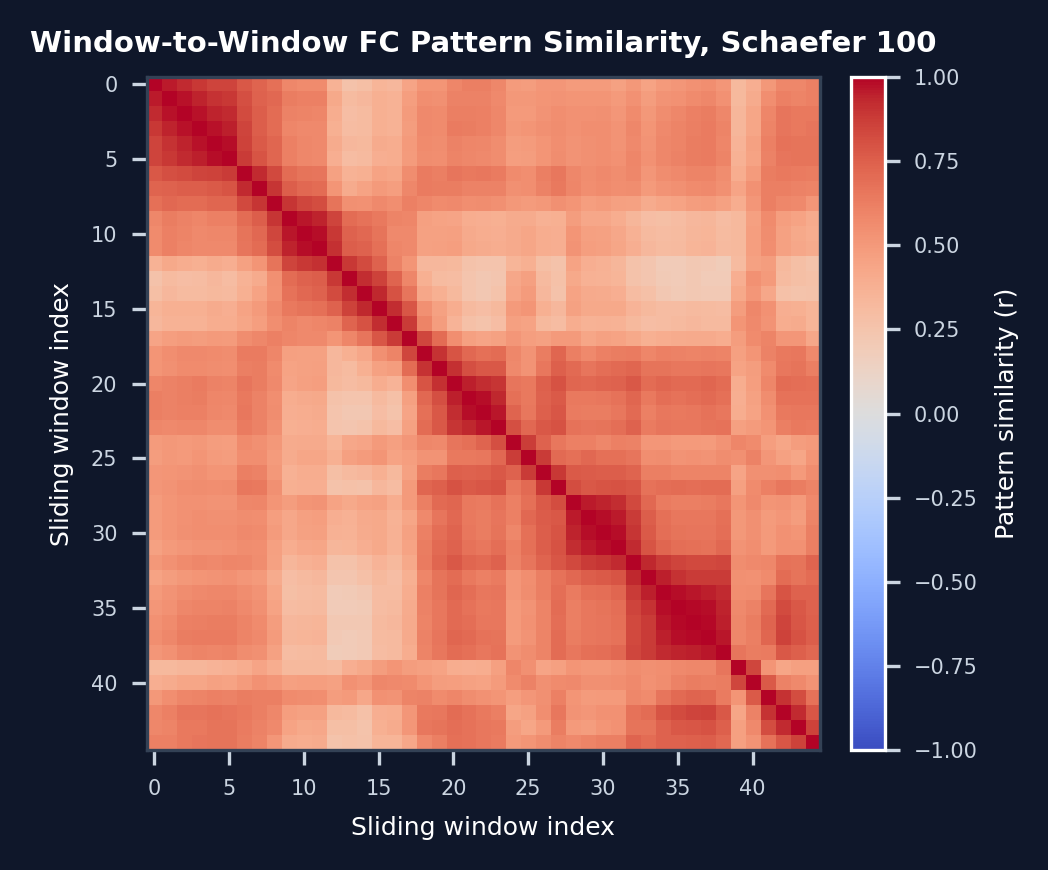

Saved: /content/figures/schaefer100_window_to_window_fc_similarity.png


In [33]:
# === Vectorize each window's upper triangle ===
edge_vectors = []

for w in range(n_windows):
    edges = mats[w][upper_idx]
    edge_vectors.append(edges)

edge_vectors = np.array(edge_vectors)

print("Edge vector array shape:", edge_vectors.shape)

# === Compute window-to-window similarity ===
window_similarity = np.corrcoef(edge_vectors)

print("Window similarity shape:", window_similarity.shape)
print("Min:", np.nanmin(window_similarity))
print("Max:", np.nanmax(window_similarity))

# === Plot ===
plt.style.use("dark_background")
fig, ax = plt.subplots(figsize=(3.5, 3), dpi=300)

im = ax.imshow(
    window_similarity,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    interpolation="nearest"
)

ax.set_title("Window-to-Window FC Pattern Similarity, Schaefer 100", fontsize=7, weight="bold", color="white")
ax.set_xlabel("Sliding window index", fontsize=6, color="white")
ax.set_ylabel("Sliding window index", fontsize=6, color="white")

ax.tick_params(colors="#cbd5e1", labelsize=5)

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Pattern similarity (r)", color="white", fontsize=6)
cbar.ax.yaxis.set_tick_params(color="#cbd5e1", labelsize=5)
plt.setp(cbar.ax.get_yticklabels(), color="#cbd5e1")

fig.patch.set_facecolor("#0f172a")
ax.set_facecolor("#0f172a")

for spine in ax.spines.values():
    spine.set_color("#334155")

out = FIG_DIR / "schaefer100_window_to_window_fc_similarity.png"
plt.tight_layout()
plt.savefig(out, dpi=300, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

print("Saved:", out)
